### Importing the Dependencies

In [1]:
##1. Predicted Costs of Medical insurance for a dataset consisting 4000+ data points across 8+ variables
#2. Performed extensive EDA, feature engineering to prepare data for modelling
#3. trained linear regression, lasso, ridge and randomforestregressor obtaining a R2 score of 0.78 from DecisionTree


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.pipeline import make_pipeline
from sklearn import set_config
from sklearn.linear_model import LinearRegression
from sklearn import metrics


### Data Collection & Analysis

In [3]:
# # loading the data from csv file to a Pandas DataFrame
df = pd.read_csv("Medical_insurance.csv",header=0)
# first 10 rows of DataFrame
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
# number of rows and columns 
df.shape

(2772, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


#### Categorical Features:
* Sex
* Smoker
* Region

In [6]:
# checking for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df['region'].value_counts().sort_values

<bound method Series.sort_values of region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64>

### Data Analysis

In [8]:
# Statistical Measure of the dataset
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1200x900 with 0 Axes>

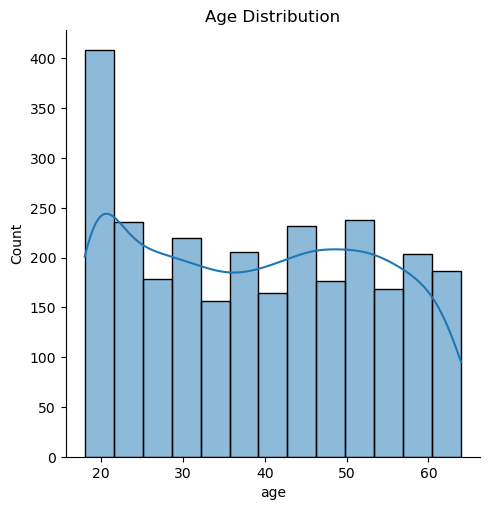

Skewness of the 'age' column: 0.061638859731918856


In [9]:
# distribution of age value
plt.figure(figsize=(12,9))
sns.displot(df['age'],kde=True)
plt.title('Age Distribution')
plt.show()
age_skewness = df['age'].skew()

print("Skewness of the 'age' column:", age_skewness)

In [10]:
print(df['sex'].value_counts().sort_values())

sex
female    1366
male      1406
Name: count, dtype: int64


<Axes: ylabel='count'>

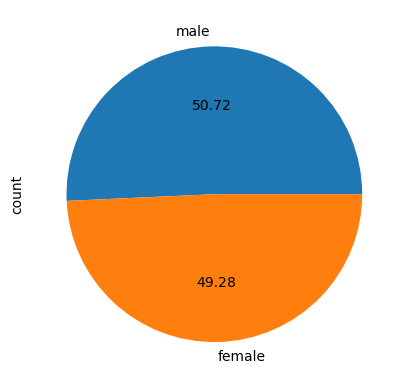

In [11]:
#Gender Column
df['sex'].value_counts().plot(kind='pie',autopct='%.2f')

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 600x600 with 0 Axes>

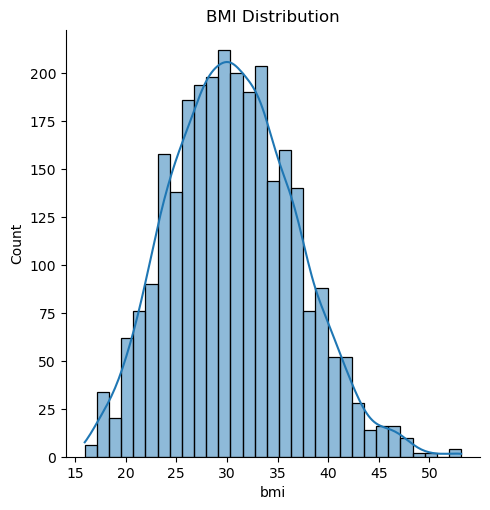

Skewness of the 'bmi' column: 0.27994423304168925


In [12]:
# bmi distribution
plt.figure(figsize=(6,6))
sns.displot(df['bmi'],kde=True)
plt.title('BMI Distribution')
plt.show()
bmi_skewness = df['bmi'].skew()

print("Skewness of the 'bmi' column:", bmi_skewness)

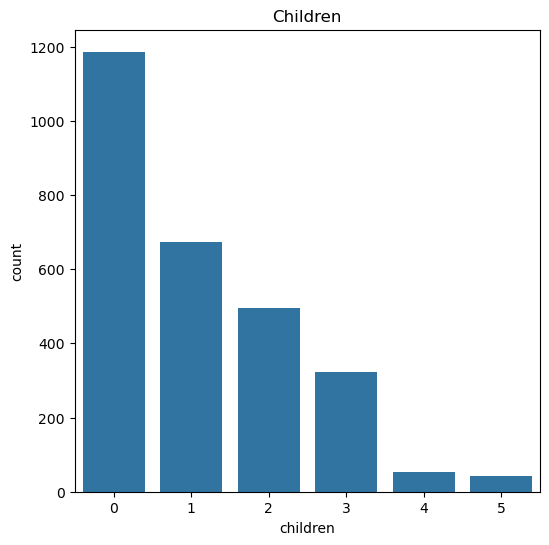

In [13]:
# children column
plt.figure(figsize=(6,6))
sns.countplot(x='children', data=df)
plt.title('Children')
plt.show()

In [14]:
df['children'].value_counts().sort_values()

children
5      42
4      52
3     324
2     496
1     672
0    1186
Name: count, dtype: int64

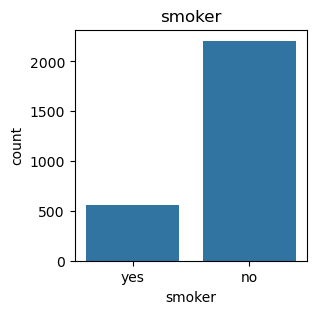

In [15]:
# smoker column
plt.figure(figsize=(3,3))
sns.countplot(x='smoker', data=df)
plt.title('smoker')
plt.show()

In [16]:
df['smoker'].value_counts().sort_values()

smoker
yes     564
no     2208
Name: count, dtype: int64

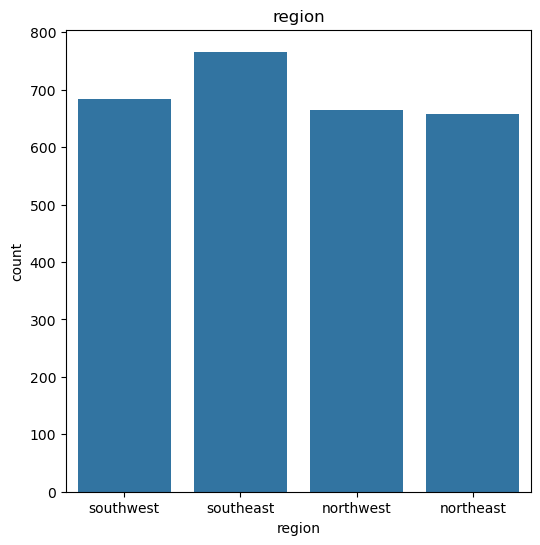

In [17]:
# region column
plt.figure(figsize=(6,6))
sns.countplot(x='region', data=df)
plt.title('region')
plt.show()

In [18]:
df['region'].value_counts().sort_values

<bound method Series.sort_values of region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64>

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 600x600 with 0 Axes>

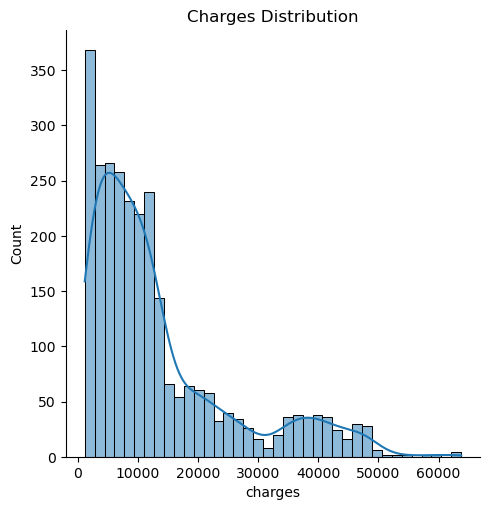

Skewness of the 'charges' column: 1.511315043602352


In [19]:
# distribution of charges value
plt.figure(figsize=(6,6))
sns.displot(df['charges'],kde=True)
plt.title('Charges Distribution')
plt.show()
charges_skewness = df['charges'].skew()

print("Skewness of the 'charges' column:", charges_skewness)

* "Given the high skewness of the 'charges' column, it is necessary to apply a transformation to address this issue."

In [20]:
df_1 =df.drop(columns=['sex','smoker','region'])

In [21]:
df_1

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
2767,47,45.320,1,8569.86180
2768,21,34.600,0,2020.17700
2769,19,26.030,1,16450.89470
2770,23,18.715,0,21595.38229


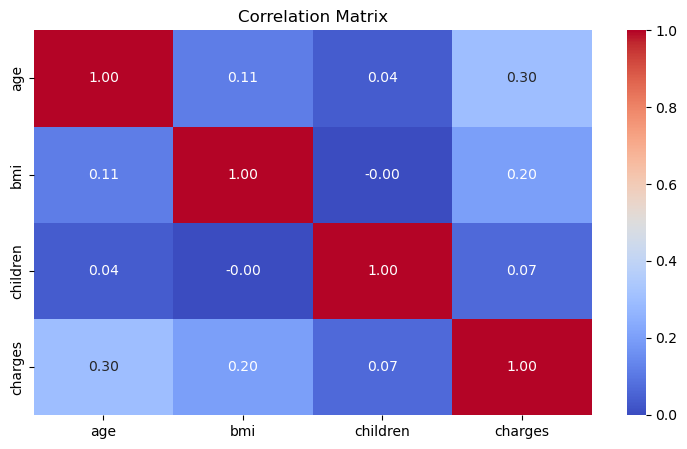

In [22]:
# Checking Features Correlation

corr = df_1.corr()

# Plot heatmap
plt.figure(figsize=(9, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

* There is no Correlation between features so here we can say that there is no Multicollinearity

In [23]:
bins = [18,24,40, 60, 70]
labels = ['18-24', '24-40','40-60', '60-70']
df['age_interval'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
interval_charge_Average = df.groupby('age_interval')['charges'].mean()

C:\Users\User\AppData\Local\Temp\ipykernel_24276\2827780035.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interval_charge_Average = df.groupby('age_interval')['charges'].mean()


Text(0, 0.5, 'Total Charges')

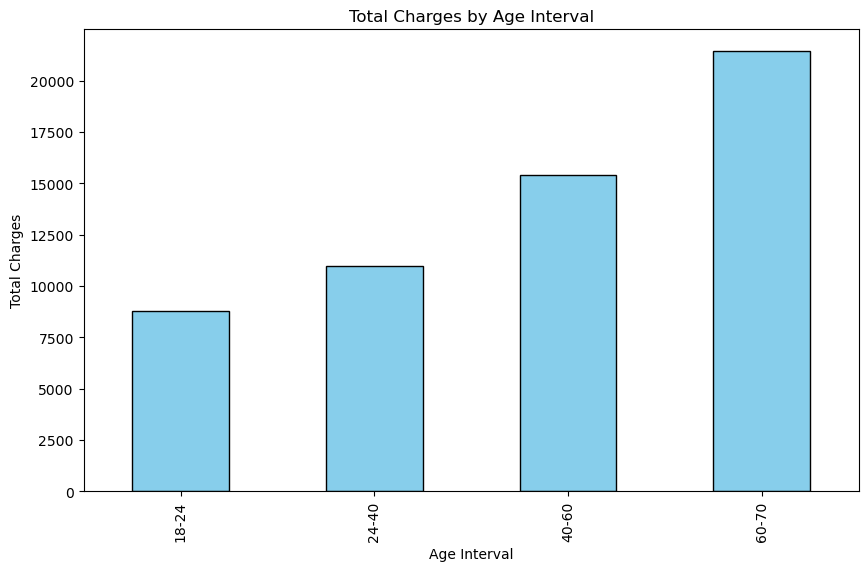

In [24]:
# Plotting
plt.figure(figsize=(10, 6))
interval_charge_Average.plot(kind='bar', color='skyblue', edgecolor='black')

# Adding titles and labels
plt.title('Total Charges by Age Interval')
plt.xlabel('Age Interval')
plt.ylabel('Total Charges')

## Data Preprocessing

In [25]:
df=df.drop(columns=['age_interval'])

In [26]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [27]:
# Spliting the Dataset into Train and Test Splits

X = df.loc[:,df.columns !='charges']
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [28]:
X.shape

(2772, 6)

In [29]:
y=df['charges']

In [30]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
2767     8569.86180
2768     2020.17700
2769    16450.89470
2770    21595.38229
2771     9850.43200
Name: charges, Length: 2772, dtype: float64

In [31]:
y.shape

(2772,)

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train.head()

,age,sex,bmi,children,smoker,region
2066,21,female,17.400,1,no,southwest
1240,52,male,41.800,2,yes,southeast
330,61,female,36.385,1,yes,northeast
2771,54,male,31.600,0,no,southwest
1238,37,male,22.705,3,no,northeast


In [33]:
print(X.shape, X_train.shape, X_test.shape)

(2772, 6) (2217, 6) (555, 6)


In [34]:
print(y.shape, y_train.shape, y_test.shape)

(2772,) (2217,) (555,)


In [35]:
# Initialize OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int32)

In [36]:
ohe =  ColumnTransformer(
    transformers=[
        ('cat', ohe, ['sex','smoker','region'])
    ],
    remainder='passthrough'  # Keep other features unchanged
)

In [37]:
X_train_new = ohe.fit_transform(X_train)

In [38]:
X_test_new = ohe.transform(X_test)

In [39]:
X_train_new.shape

(2217, 8)

In [40]:
X_train_new

array([[ 0.   ,  0.   ,  0.   , ..., 21.   , 17.4  ,  1.   ],
       [ 1.   ,  1.   ,  0.   , ..., 52.   , 41.8  ,  2.   ],
       [ 0.   ,  1.   ,  0.   , ..., 61.   , 36.385,  1.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ..., 59.   , 32.395,  3.   ],
       [ 1.   ,  0.   ,  0.   , ..., 40.   , 24.97 ,  2.   ],
       [ 0.   ,  0.   ,  1.   , ..., 58.   , 28.215,  0.   ]])

In [41]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# transform train and test sets
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

In [42]:
regressor = LinearRegression()

In [43]:
regressor.fit(X_train_scaled, y_train)

LinearRegression()

In [44]:
# prediction on training data
training_data_prediction =regressor.predict(X_train_scaled)

In [45]:
 # R squared value
r2_train = metrics.r2_score(y_train, training_data_prediction)
print('R squared vale : ', r2_train)

R squared vale :  0.7518057676080019


In [46]:
# Mse value
mse = metrics.mean_squared_error(y_train,training_data_prediction)
rmse = np.sqrt(mse)
print(f' Root Mean Squared Error on train set: {rmse}')

 Root Mean Squared Error on train set: 6044.445331830097


In [47]:
# prediction on test data
test_data_prediction =regressor.predict(X_test_scaled)

In [48]:
# R squared value
r2_test = metrics.r2_score(y_test, test_data_prediction)
print('R squared vale : ', r2_test)

R squared vale :  0.7465278904179782


In [49]:
# Mse value
mse = metrics.mean_squared_error(y_test,test_data_prediction)
rmse = np.sqrt(mse)
print(f' Root Mean Squared Error on train set: {rmse}')

 Root Mean Squared Error on train set: 6146.136441623573


In [50]:
from sklearn.linear_model import Ridge

In [51]:
# Define the Ridge model and the parameter grid
ridge = Ridge()
alpha_values = np.logspace(-4, 4, 100) #This specifies the number of values to generate between 10^-4 to 10^4 inclusive
param_grid = {'alpha': alpha_values}

In [52]:
# Perform GridSearch with Cross-Validation
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, 
                           scoring='neg_mean_squared_error', cv=5) 
#neg_mean_squared_error: The scoring metric used to evaluate the model’s performance (negative because GridSearchCV tries to maximize the score).

In [53]:
# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03, 1.62975083e-03,
       1.96304065e-03, 2.36448941e-03, 2.84803587e-03, 3....
       1.38488637e+02, 1.66810054e+02, 2.00923300e+02, 2.42012826e+02,
       2.91505306e+02, 3.51119173e+02, 4.22924287e+02, 5.09413801e+02,
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04])},
             scoring='neg_mean_squared_error')

In [54]:
# Retrieve the best lambda and evaluate the model


best_alpha = grid_search.best_params_['alpha']
best_alpha

0.6280291441834259

In [55]:
# ridge regression with best_alpha
best_ridge = Ridge(alpha=best_alpha)

In [56]:
# fitting ridge regression model(for best value of alpha)
best_ridge.fit(X_train_scaled, y_train)
y_train_pred = best_ridge.predict(X_train_scaled)

In [57]:
# Calculate the performance metric(for training dataset)
mse = metrics.mean_squared_error(y_train, y_train_pred)
r2_score_ridge = metrics.r2_score(y_train, y_train_pred)
rmse = np.sqrt(mse)
print(f'Best lambda (alpha): {best_alpha}')
print(f'Root Mean Squared Error on test set: {rmse}')
print('R squared vale : ', r2_score_ridge)

Best lambda (alpha): 0.6280291441834259
Root Mean Squared Error on test set: 6044.470901130158
R squared vale :  0.7518036677738977


In [58]:
y_pred = best_ridge.predict(X_test_scaled)

In [59]:
# Calculate the performance metric
mse = metrics.mean_squared_error(y_test, y_pred)
r2_score_ridge = metrics.r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Best lambda (alpha): {best_alpha}')
print(f'Root Mean Squared Error on test set: {rmse}')
print('R squared vale : ', r2_score_ridge)

Best lambda (alpha): 0.6280291441834259
Root Mean Squared Error on test set: 6145.751692800116
R squared vale :  0.7465596241890678


In [60]:
from sklearn.linear_model import Lasso

In [61]:
# Define the Ridge model and the parameter grid
lasso = Lasso()
alpha_values = np.logspace(-4, 4, 100) #This specifies the number of values to generate between 10^-4 to 10^4 inclusive
param_grid_1 = {'alpha': alpha_values}

In [62]:
# Perform GridSearch with Cross-Validation
grid_search = GridSearchCV(estimator=lasso, param_grid=param_grid_1, 
                           scoring='neg_mean_squared_error', cv=5) 
#neg_mean_squared_error: The scoring metric used to evaluate the model’s performance (negative because GridSearchCV tries to maximize the score).

In [63]:
# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03, 1.62975083e-03,
       1.96304065e-03, 2.36448941e-03, 2.84803587e-03, 3....
       1.38488637e+02, 1.66810054e+02, 2.00923300e+02, 2.42012826e+02,
       2.91505306e+02, 3.51119173e+02, 4.22924287e+02, 5.09413801e+02,
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04])},
             scoring='neg_mean_squared_error')

In [64]:
# Retrieve the best lambda and evaluate the model


best_alpha = grid_search.best_params_['alpha']
best_alpha

7.054802310718645

In [65]:
# Lasso regression with best_alpha
best_lasso = Lasso(alpha=best_alpha)

In [66]:
# fitting ridge regression model(for best value of alpha)
best_lasso.fit(X_train_scaled, y_train)
y_pred = best_lasso.predict(X_test_scaled)


In [67]:
# Calculate the performance metric
mse = metrics.mean_squared_error(y_test, y_pred)
r2_score_ridge = metrics.r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Best lambda (alpha): {best_alpha}')
print(f'Root Mean Squared Error on test set: {rmse}')
print('R squared vale : ', r2_score_ridge)

Best lambda (alpha): 7.054802310718645
Root Mean Squared Error on test set: 6144.570213911146
R squared vale :  0.746657059193436


In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
# Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model
rf.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [70]:
y_train_pred1 = rf.predict(X_train_scaled)

In [71]:
y_test_pred1 = rf.predict(X_test_scaled)

In [72]:
# Calculate the performance metric for test dataset
mse_rf = metrics.mean_squared_error(y_test, y_test_pred1)
r2_score_rf = metrics.r2_score(y_test, y_test_pred1)
rmse_rf = np.sqrt(mse_rf)
print(f'Root Mean Squared Error on test set: {rmse_rf}')
print('R squared vale : ', r2_score_rf)

Root Mean Squared Error on test set: 2385.3059522272156
R squared vale :  0.9618219300958736


In [73]:
# Calculate the performance metric for train dataset
mse_rf_train = metrics.mean_squared_error(y_train, y_train_pred1)
r2_score_rf_train = metrics.r2_score(y_train, y_train_pred1)
rmse_rf = np.sqrt(mse_rf_train)
print(f'Root Mean Squared Error on test set: {rmse_rf}')
print('R squared vale : ', r2_score_rf_train)

Root Mean Squared Error on test set: 1152.215725477428
R squared vale :  0.9909812494820689
